# test_heater_01_mode — BC modes x wall_config matrix

Systematic verification of all valid boundary condition mode / wall model combinations.

`shell_tube=True` means `wall_config` is present: the wall has its own thermal mass
and temperature ODE state. It is NOT a shell-side fluid. The exterior BC (what heats
or cools the wall from outside) is still governed by `thermal_bc_config`.

| Mode | wall_config=None (static wall) | wall_config present (dynamic wall) |
|------|-------------------------------|-------------------------------------|
| `adiabatic` | A | B |
| `heatfluxwall` | C | D |
| `fixed_twall` | E | incompatible (Tw cannot be both ODE state and fixed) |
| `ambient_htc` | F | G |

In [31]:
import os, sys, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.units.heater.config.gas_props  import build_gas_prop_config
from src.units.heater.config.boundary_c import build_boundary_c_config
from src.units.heater.config.thermal_bc import build_thermal_bc_config
from src.units.heater.config.transport  import build_transport_config
from src.units.heater.config.initial_c  import build_initial_c_config
from src.units.heater.config.wall_c     import build_wall_config
from src.units.heater.state             import pack_state_vector
from src.solvers.runner_heater          import run_step

ROOT     = os.path.abspath('..')
DB_GAS   = os.path.join(ROOT, 'materials', 'fluids',  'gasdb.txt')
DB_SOLID = os.path.join(ROOT, 'materials', 'solids', 'soliddb.txt')
print('Imports OK')

Imports OK


In [32]:
# ── Common parameters ─────────────────────────────────────────────────────────
N       = 11
L       = 0.75        # m
Di      = 0.08        # m
Do      = 0.09        # m
e_wall  = (Do - Di) / 2.0
dz      = L / N
Ai      = 0.25 * np.pi * Di**2
Pi      = np.pi * Di
Po      = np.pi * Do

nc      = 1
SPECIES = ['N2']

T_INIT  = 350.0       # K  initial gas AND wall temperature
T_IN    = 350.0       # K  inlet gas temperature
P_INIT  = 1.01325     # bar
P_OUT   = 1.01325     # bar
V_IN    = 1.0         # m/s

T_WALL_F = 500.0      # K  (fixed_twall mode)
Q_WALL   = 100.0      # W  (heatfluxwall mode)
H_AMBI   = 20.0       # W/m2K  (ambient_htc mode)
T_AMBI   = 300.0      # K      (ambient_htc mode: T_AMBI < T_IN => net cooling)
K_WALL_A = 16.0       # W/mK   (ambient_htc mode)

T_MAX   = 60.0        # s

print(f'L={L}m  Di={Di}m  Do={Do}m  N={N}  dz={dz:.4f}m')
print(f'Ai={Ai*1e4:.3f}cm2  T_INIT={T_INIT}K  T_IN={T_IN}K')

L=0.75m  Di=0.08m  Do=0.09m  N=11  dz=0.0682m
Ai=50.265cm2  T_INIT=350.0K  T_IN=350.0K


In [33]:
# ── Shared prop_gas and initial state (reused by all cases) ───────────────────
prop_gas  = build_gas_prop_config(species=SPECIES, mode='polynomial', n_comp=nc, N=N,
                                   T_ref=T_INIT, db_path=DB_GAS)
gas_T_ref = float(np.min(np.asarray(prop_gas['Tref'])))

y_init  = np.ones((nc, N), dtype=float)
P_arr   = np.full(N, P_INIT)
Tg_arr0 = np.full(N, T_INIT)
ic = build_initial_c_config(P_init=P_arr, Tg_init=Tg_arr0, y_init=y_init,
                              n_comp=nc, N=N, prop_gas=prop_gas, gas_T_ref=gas_T_ref)
sv0_gas = pack_state_vector(C=ic['C_init'], Hg=ic['Hg_init'])

print(f'sv0_gas.shape = {sv0_gas.shape}   (nc+1)*N = {(nc+1)*N}')
print(f'gas_T_ref = {gas_T_ref:.1f} K')

sv0_gas.shape = (22,)   (nc+1)*N = 22
gas_T_ref = 298.0 K


In [34]:
# ── Helper: build params and run ──────────────────────────────────────────────
def run_case(mode, dynamic_wall=False):
    """
    dynamic_wall=True  => wall_config present, Tw is an ODE state.
    dynamic_wall=False => no wall_config, static-wall assumption.
    Wall initialised at T_INIT in both cases (no artificial initial gradient).
    """
    bc  = build_boundary_c_config(n_comp=nc, v_in=V_IN, T_in=T_IN,
                                   y_in=np.array([1.0]), P_out=P_OUT)

    kw = dict(mode=mode, Di=Di, Do=Do, e_wall=e_wall)
    if mode == 'heatfluxwall': kw['Qwall'] = Q_WALL
    elif mode == 'fixed_twall': kw['T_wall'] = T_WALL_F
    elif mode == 'ambient_htc': kw.update(h_ambi=H_AMBI, T_ambi=T_AMBI, k_wall=K_WALL_A)
    tbc = build_thermal_bc_config(**kw)

    tr = build_transport_config(mode='correlation', N=N)

    params = dict(
        n_comp=nc, N=N, dz=dz, Ai=Ai, Di=Di, Pi=Pi, Po=Po,
        prop_gas=prop_gas, MW=np.asarray(prop_gas['MW']),
        gas_T_ref=gas_T_ref,
        bc_config=bc, trans_config=tr, thermal_bc_config=tbc,
        energy=True, prop_update_mode='always', trans_update_mode='always',
        species=SPECIES, _cache={},
    )

    sv0 = sv0_gas.copy()

    if dynamic_wall:
        # Wall starts at T_INIT — same as gas, no artificial initial gradient
        wall_cfg = build_wall_config(N=N, Di=Di, Do=Do, T_w_init=T_INIT,
                                      material_id='SS316L', db_path=DB_SOLID)
        params['wall_config'] = wall_cfg
        sv0 = pack_state_vector(C=ic['C_init'], Hg=ic['Hg_init'],
                                 Tw=np.full(N, T_INIT))

    t0 = time.perf_counter()
    _, _, heater = run_step(sv0=sv0, t_max=T_MAX, params=params,
                             solver='solve_ivp', rtol=1e-7, atol=1e-9, n_sec=5)
    cpu = time.perf_counter() - t0
    return heater, cpu


def row(label, heater, cpu):
    Tg = heater._Tg_results[-1]
    d  = dict(case=label, Tg_in_K=round(Tg[0],2), Tg_out_K=round(Tg[-1],2),
               DeltaT_K=round(Tg[-1]-Tg[0],2),
               P_out_bar=round(heater._P_results[-1,-1],5), cpu_s=round(cpu,1))
    if hasattr(heater, '_Tw_results'):
        d['Tw_out_K'] = round(heater._Tw_results[-1,-1], 2)
    return d

rows = []
print('Helper OK')

Helper OK


## A · adiabatic — static wall

In [35]:
h_A, cpu_A = run_case('adiabatic', dynamic_wall=False)
Tg_A = h_A._Tg_results[-1]

# No heat source, inlet = T_IN => steady-state outlet must equal inlet
assert abs(Tg_A[-1] - T_IN) < 2.0, f'adiabatic: outlet must equal inlet, got {Tg_A[-1]:.2f}K'

rows.append(row('A_adiabatic_static', h_A, cpu_A))
print(f'A OK — Tg_out={Tg_A[-1]:.2f}K  (expect ~{T_IN}K)  [{cpu_A:.1f}s]')

A OK — Tg_out=350.00K  (expect ~350.0K)  [0.6s]


## B · adiabatic — dynamic wall (wall_config present)

In [36]:
h_B, cpu_B = run_case('adiabatic', dynamic_wall=True)
Tg_B = h_B._Tg_results[-1]
Tw_B = h_B._Tw_results[-1]

# Adiabatic exterior + wall starts at T_INIT = T_IN => no net heat source
# Gas and wall stay near T_INIT; Tw accessible as ODE state
assert abs(Tg_B[-1] - T_IN) < 3.0, f'adiabatic+wall: outlet must stay near T_IN, got {Tg_B[-1]:.2f}K'
assert Tw_B.shape == (N,), 'Tw must be accessible as ndarray(N,)'
assert np.all(np.isfinite(Tw_B)), 'Tw must be finite'

rows.append(row('B_adiabatic_wall', h_B, cpu_B))
print(f'B OK — Tg_out={Tg_B[-1]:.2f}K  Tw_out={Tw_B[-1]:.2f}K  [{cpu_B:.1f}s]')

B OK — Tg_out=350.00K  Tw_out=350.00K  [1.0s]


## C · heatfluxwall — static wall

In [37]:
h_C, cpu_C = run_case('heatfluxwall', dynamic_wall=False)
Tg_C = h_C._Tg_results[-1]

# Q_WALL > 0 => gas heats up; outlet must be warmer than inlet
assert Tg_C[-1] > T_IN + 1.0, f'heatflux static: outlet must be heated, got {Tg_C[-1]:.2f}K'

rows.append(row('C_heatflux_static', h_C, cpu_C))
print(f'C OK — Tg_out={Tg_C[-1]:.2f}K  [{cpu_C:.1f}s]')

C OK — Tg_out=369.46K  [1.4s]


## D · heatfluxwall — dynamic wall

In [38]:
h_D, cpu_D = run_case('heatfluxwall', dynamic_wall=True)
Tg_D = h_D._Tg_results[-1]
Tw_D = h_D._Tw_results[-1]

# Q_WALL heats the wall exterior; wall then conducts to gas.
# SS316L wall (Di=0.08, Do=0.09, L=0.75m) has thermal mass ~4000 J/K >>
# gas thermal mass ~5 J/K => most of Q_WALL is stored in the wall at t=T_MAX.
# Gas heating is small but positive; 0.1 K threshold checks direction only.
assert Tg_D[-1] > T_IN + 0.1, f'heatflux+wall: gas must heat above inlet, got {Tg_D[-1]:.3f}K'
assert Tw_D[-1] > T_INIT,     f'heatflux+wall: wall must rise above T_INIT, got {Tw_D[-1]:.3f}K'
# Wall absorbs most heat => Tg_D well below Tg_C (no-wall case)
assert Tg_D[-1] < Tg_C[-1], \
    f'heatflux+wall: wall should buffer heating; Tg_D={Tg_D[-1]:.3f} Tg_C={Tg_C[-1]:.3f}'

rows.append(row('D_heatflux_wall', h_D, cpu_D))
print(f'D OK — Tg_out={Tg_D[-1]:.3f}K (+{Tg_D[-1]-T_IN:.4f}K)  Tw_out={Tw_D[-1]:.3f}K (+{Tw_D[-1]-T_INIT:.4f}K)  [{cpu_D:.1f}s]')
print(f'  Without wall (C): Tg_out={Tg_C[-1]:.2f}K — wall absorbs most of Q_WALL')

D OK — Tg_out=350.276K (+0.2758K)  Tw_out=351.482K (+1.4822K)  [0.7s]
  Without wall (C): Tg_out=369.46K — wall absorbs most of Q_WALL


## E · fixed_twall — static wall  (dynamic wall incompatible)

In [39]:
h_E, cpu_E = run_case('fixed_twall', dynamic_wall=False)
Tg_E = h_E._Tg_results[-1]

assert Tg_E[-1] > T_IN + 1.0, f'fixed_twall: outlet must heat up, got {Tg_E[-1]:.2f}K'
assert Tg_E[-1] < T_WALL_F,   f'fixed_twall: outlet must stay below T_wall={T_WALL_F}K'

rows.append(row('E_fixed_twall', h_E, cpu_E))
print(f'E OK — Tg_out={Tg_E[-1]:.2f}K  (T_wall={T_WALL_F}K)  [{cpu_E:.1f}s]')
print('  Note: fixed_twall + dynamic_wall is incompatible => not tested.')

E OK — Tg_out=390.26K  (T_wall=500.0K)  [1.2s]
  Note: fixed_twall + dynamic_wall is incompatible => not tested.


## F · ambient_htc — static wall

In [40]:
h_F, cpu_F = run_case('ambient_htc', dynamic_wall=False)
Tg_F = h_F._Tg_results[-1]

# T_AMBI=300K < T_IN=350K => gas loses heat to ambient
assert Tg_F[-1] < T_IN - 1.0, f'ambient_htc: gas must cool, got {Tg_F[-1]:.2f}K'
assert Tg_F[-1] > T_AMBI,     f'ambient_htc: gas cannot cool below ambient, got {Tg_F[-1]:.2f}K'

rows.append(row('F_ambient_static', h_F, cpu_F))
print(f'F OK — Tg_out={Tg_F[-1]:.2f}K  (T_ambi={T_AMBI}K)  [{cpu_F:.1f}s]')

F OK — Tg_out=340.85K  (T_ambi=300.0K)  [0.6s]


## G · ambient_htc — dynamic wall

In [41]:
h_G, cpu_G = run_case('ambient_htc', dynamic_wall=True)
Tg_G = h_G._Tg_results[-1]
Tw_G = h_G._Tw_results[-1]

# Ambient cools the wall; wall cools gas => net cooling
assert Tg_G[-1] < T_IN - 0.5, f'ambient_htc+wall: gas must cool, got {Tg_G[-1]:.2f}K'
assert Tw_G[-1] < T_INIT,     f'ambient_htc+wall: wall must cool below T_INIT, got {Tw_G[-1]:.2f}K'
# Wall thermal mass buffers cooling => Tg_G >= Tg_F (less cooling than static wall)
assert Tg_G[-1] >= Tg_F[-1] - 1.0, \
    f'ambient_htc+wall: wall buffers cooling; Tg_G={Tg_G[-1]:.2f} Tg_F={Tg_F[-1]:.2f}'

rows.append(row('G_ambient_wall', h_G, cpu_G))
print(f'G OK — Tg_out={Tg_G[-1]:.2f}K  Tw_out={Tw_G[-1]:.2f}K  [{cpu_G:.1f}s]')
print(f'  (F without wall: Tg_out={Tg_F[-1]:.2f}K — wall buffers cooling)')

G OK — Tg_out=349.43K  Tw_out=346.97K  [0.8s]
  (F without wall: Tg_out=340.85K — wall buffers cooling)


## Summary

In [42]:
df = pd.DataFrame(rows).set_index('case').fillna('-')
print(df.to_string())
print('\nAll assertions passed  OK')

                    Tg_in_K  Tg_out_K  DeltaT_K  P_out_bar  cpu_s Tw_out_K
case                                                                      
A_adiabatic_static   350.00    350.00      0.00    1.01325    0.6        -
B_adiabatic_wall     350.00    350.00      0.00    1.01325    1.0    350.0
C_heatflux_static    351.77    369.46     17.69    1.06959    1.4        -
D_heatflux_wall      350.03    350.28      0.25    1.01405    0.7   351.48
E_fixed_twall        354.25    390.26     36.01    1.12980    1.2        -
F_ambient_static     349.08    340.85     -8.22    0.98678    0.6        -
G_ambient_wall       349.94    349.43     -0.52    1.01159    0.8   346.97

All assertions passed  OK


## Axial profiles — static vs dynamic wall

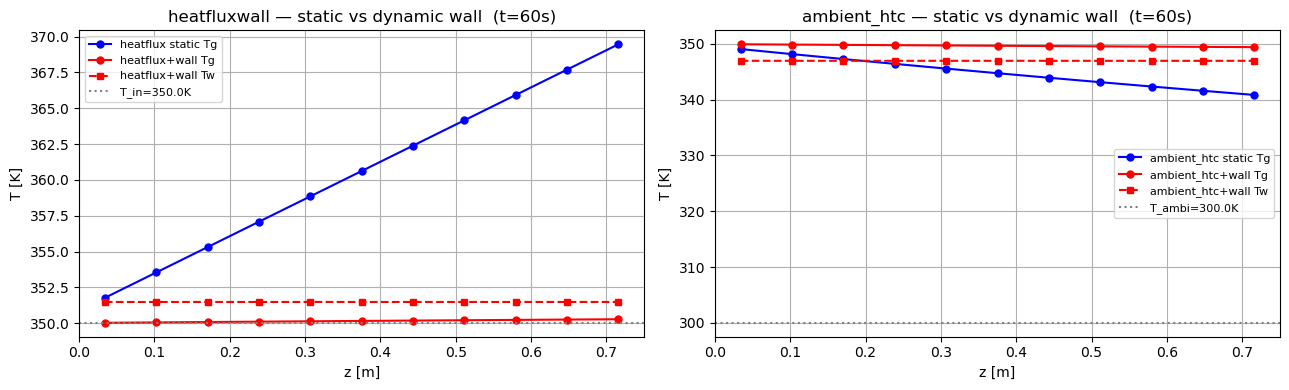

In [43]:
z = np.linspace(dz/2, L - dz/2, N)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(z, h_C._Tg_results[-1], 'b-o', ms=5, label='heatflux static Tg')
ax.plot(z, h_D._Tg_results[-1], 'r-o', ms=5, label='heatflux+wall Tg')
ax.plot(z, h_D._Tw_results[-1], 'r--s', ms=4, label='heatflux+wall Tw')
ax.axhline(T_IN, color='gray', ls=':', label=f'T_in={T_IN}K')
ax.set_xlabel('z [m]'); ax.set_ylabel('T [K]')
ax.set_title(f'heatfluxwall — static vs dynamic wall  (t={T_MAX:.0f}s)')
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.plot(z, h_F._Tg_results[-1], 'b-o', ms=5, label='ambient_htc static Tg')
ax.plot(z, h_G._Tg_results[-1], 'r-o', ms=5, label='ambient_htc+wall Tg')
ax.plot(z, h_G._Tw_results[-1], 'r--s', ms=4, label='ambient_htc+wall Tw')
ax.axhline(T_AMBI, color='gray', ls=':', label=f'T_ambi={T_AMBI}K')
ax.set_xlabel('z [m]'); ax.set_ylabel('T [K]')
ax.set_title(f'ambient_htc — static vs dynamic wall  (t={T_MAX:.0f}s)')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.show()